#### Evaluating the model

## What is ROC and AUC?

**ROC Curve:** It’s a plot of True Positive Rate (TPR) vs False Positive Rate (FPR) at various threshold settings.

TPR (Recall) = TP / (TP + FN)

FPR = FP / (FP + TN)

**AUC (Area Under the Curve):** It tells how much the model is capable of distinguishing between classes.

AUC = 1: Perfect classifier

AUC = 0.5: No discrimination (random guessing)

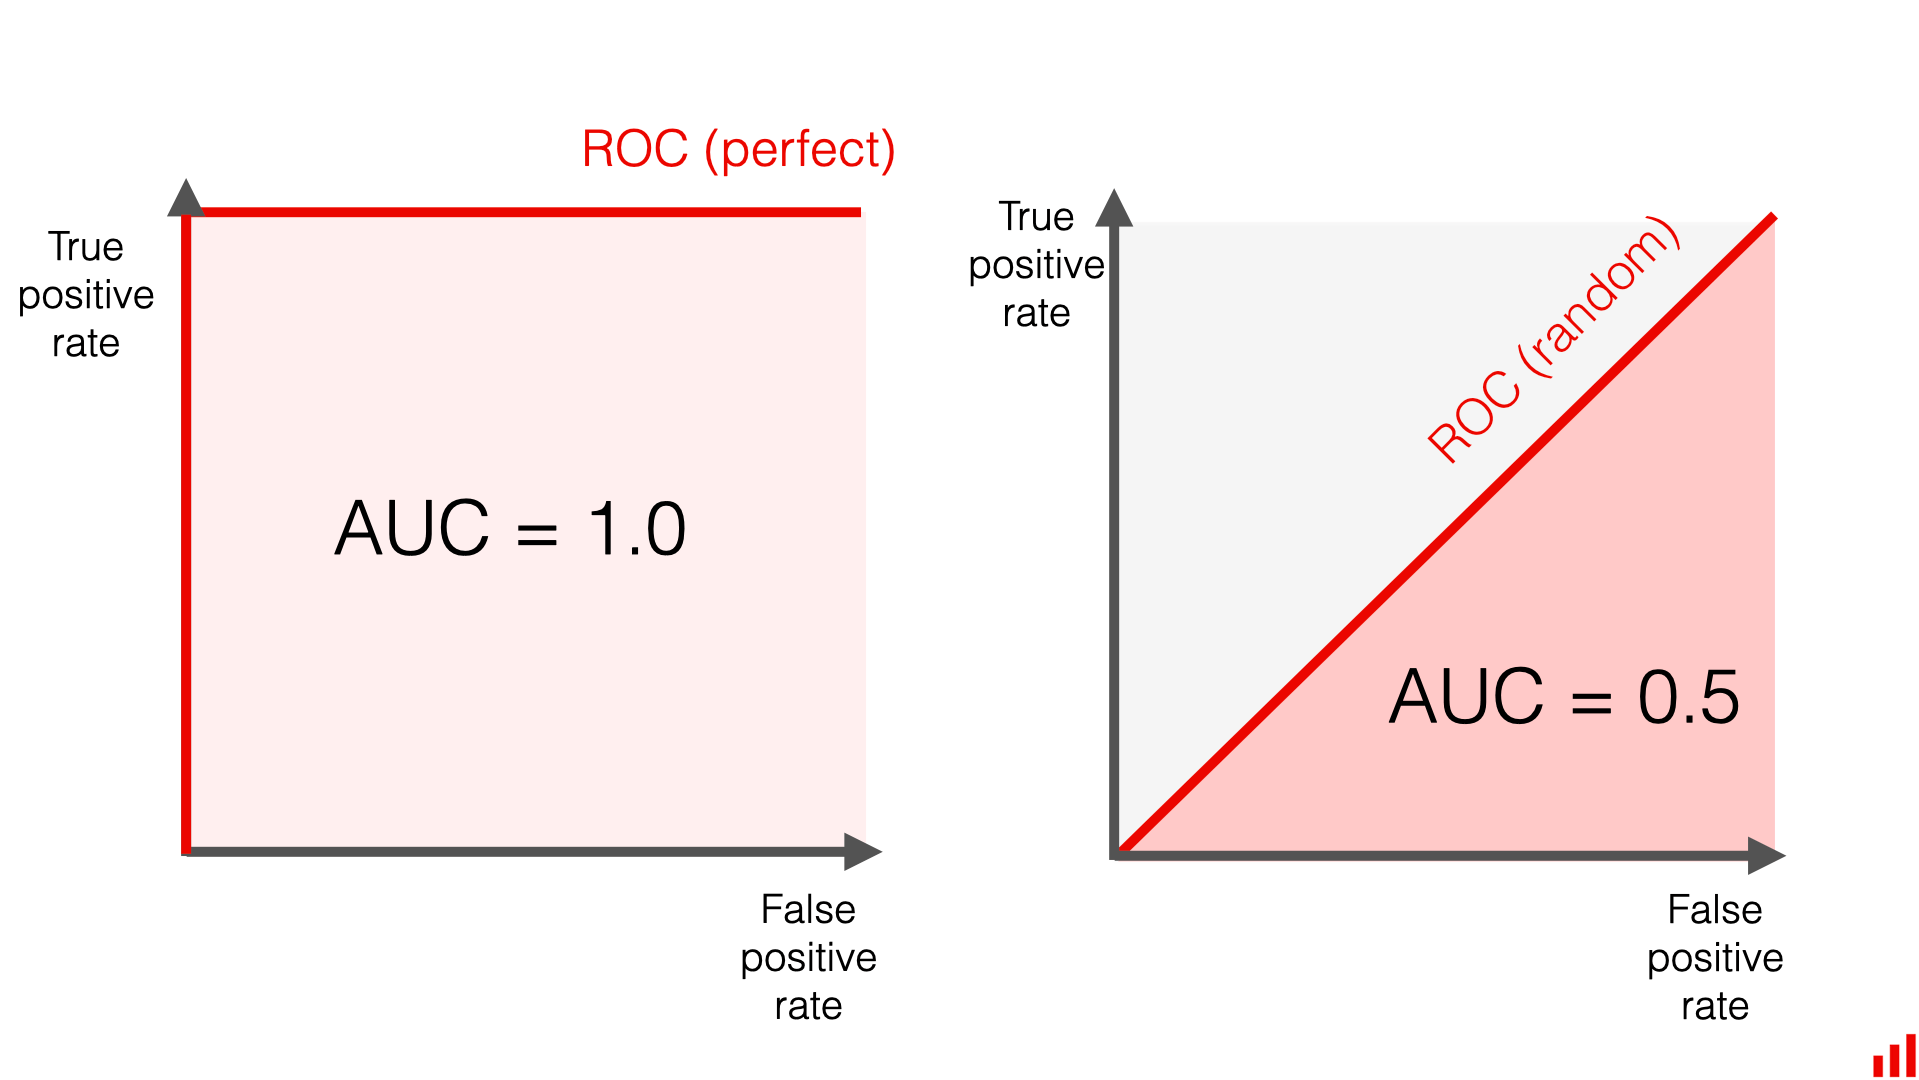

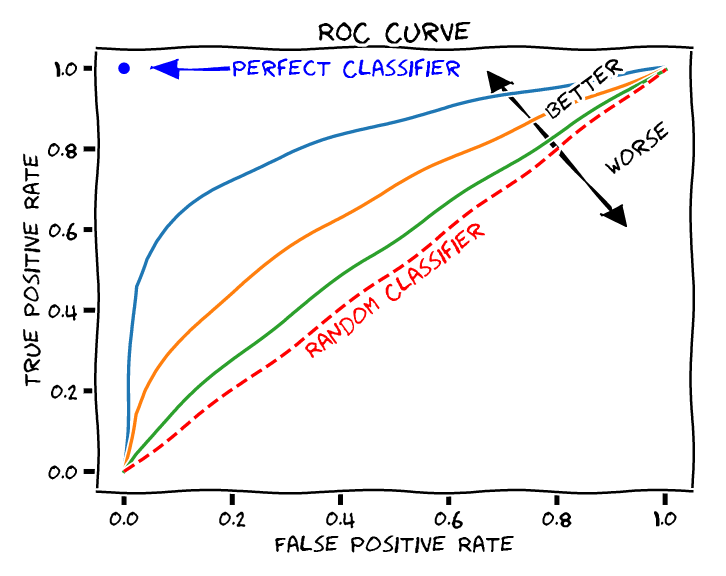

## Step 1: Load and Preprocess Titanic Dataset

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns

# Load dataset
df = sns.load_dataset('titanic')

# Select features and drop rows with missing important values
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].dropna()

# Convert categorical to numeric
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Define features and target
X = df.drop('survived', axis=1)
y = df['survived']


## Step 2: Train-Test Split + Scaling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 3: Train Multiple Models


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM (probability)": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}


## Step 4: Compute ROC & AUC and Plot

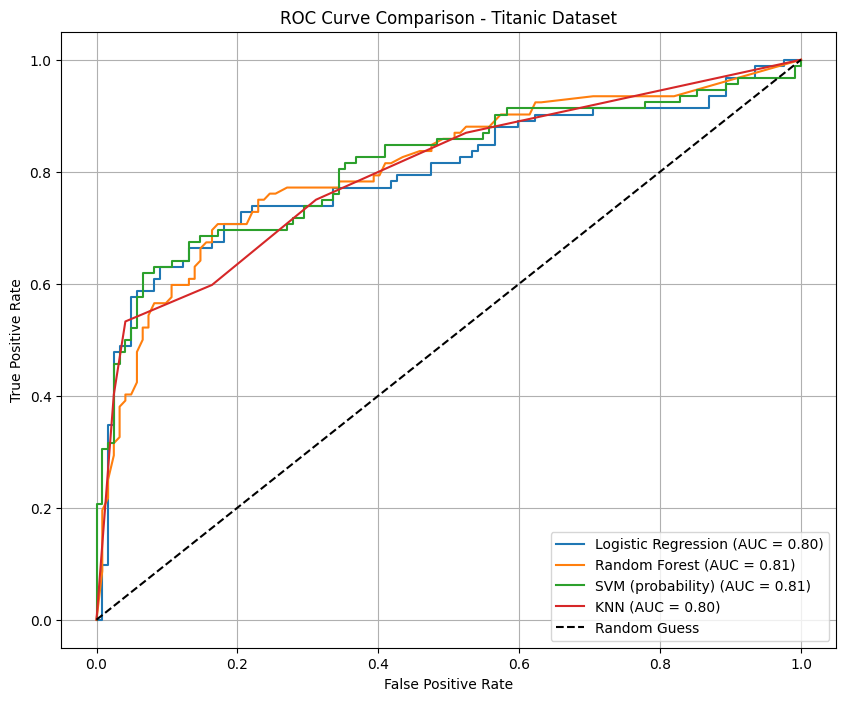

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Fit
    model.fit(X_train_scaled, y_train)

    # Predict probabilities for class 1 (survived)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Titanic Dataset")
plt.legend(loc="lower right")
plt.grid()
plt.show()


## Step 5: Interpretation

Closer to top-left = Better performance

AUC Score near 1.0: Excellent model

AUC ~0.5: Useless (like guessing)

## Multiclass Confusion Matrix


## Step 1: Load Data & Split


In [15]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Step 2: Train Two Models

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

## Step 3: Multiclass Confusion Matrix & Accuracy

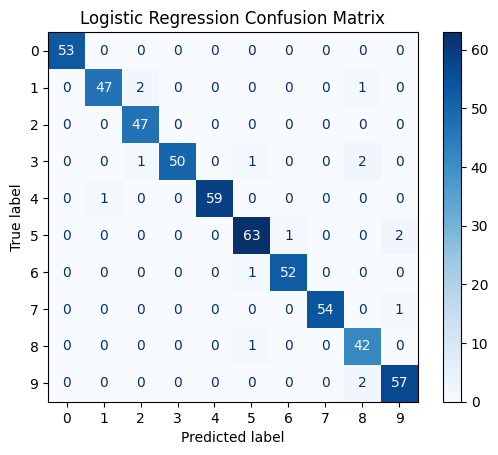

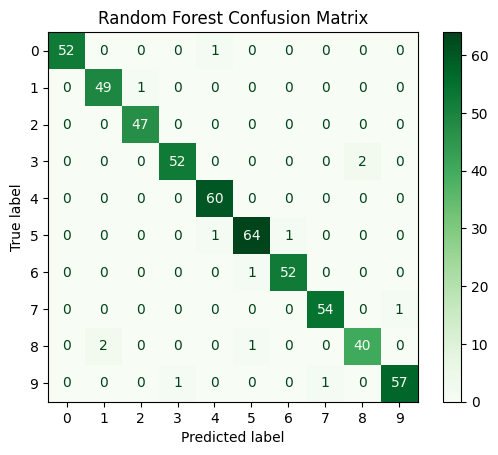

Logistic Regression Accuracy: 0.9703703703703703
Random Forest Accuracy: 0.975925925925926


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=digits.target_names).plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=digits.target_names).plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Accuracy comparison
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

## How to Interpret a Multiclass Confusion Matrix (10 classes)?

Diagonal cells = correct predictions

Off-diagonal cells = misclassifications

Look at which digits are confused most (e.g., 4s predicted as 5s)

## Advanced Evaluation

- **Precision** = What % of predicted positives were *actually* positive?  
  > *"How accurate are my positive predictions?"*

- **Recall** = What % of actual positives were correctly predicted?  
  > *"How well did I find all the real positives?"*

- **F1 Score** = The balance between precision and recall (harmonic mean).  
  > *"How good is the model overall at finding positives accurately?"*

### Formulae:
- Precision = TP / (TP + FP)  
- Recall = TP / (TP + FN)  
- F1 Score = 2 × (Precision × Recall) / (Precision + Recall)

Where:
- TP = True Positives  
- FP = False Positives  
- FN = False Negatives

In [18]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, y_pred_log, target_names=digits.target_names.astype(str)))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=digits.target_names.astype(str)))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.94      0.96        50
           2       0.94      1.00      0.97        47
           3       1.00      0.93      0.96        54
           4       1.00      0.98      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.89      0.98      0.93        43
           9       0.95      0.97      0.96        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540

Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.96      0.98      0.97        50
           2       0.98      1.00      0.9

## Final Verdict
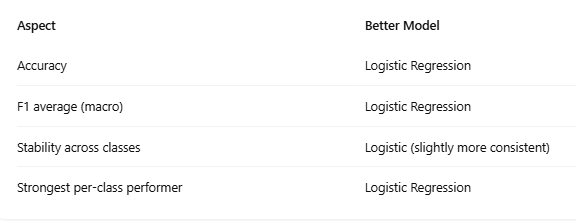

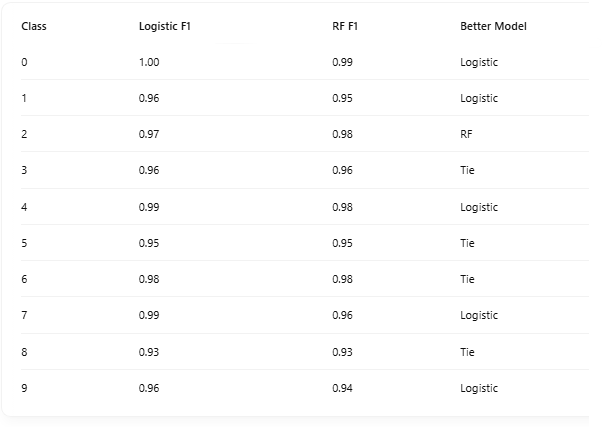

## Regression

In [19]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

In [20]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [21]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Load the data
data = fetch_california_housing()
X, y = data.data, data.target

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Linear Regression
<p align="center">
<img src="https://cdn.nextjournal.com/data/QmfPuPp4V74FyvTTojMj6ix9T8Skj1ji4GhX5Pr6zK8w4N?filename=linear-regression.png&content-type=image/png" width="500"
</p>

In [22]:
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
regr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Evaluating the model

In [23]:
regr.score(X_test, y_test)

0.5757877060324521

In [24]:
print("The Training accuracy of the model is {:.2f}".format(regr.score(X_train, y_train)))
print("The Testing accuracy of the model is {:.2f}".format(regr.score(X_test, y_test)))

The Training accuracy of the model is 0.61
The Testing accuracy of the model is 0.58


In [25]:
predictions = regr.predict(X_test)
print(predictions)

[0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]


In [26]:
print("The coefficients of the function are {}".format(regr.coef_))
print("The intercept of the function is {}".format(regr.intercept_))

The coefficients of the function are [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
The intercept of the function is -37.02327770606397


## Regressions Metrics


**R² Score (R-squared)**

Measures how well the model explains the variation in the target variable.

Value ranges from 0 to 1 (can be negative if really bad).

1 = perfect prediction, 0 = predicts mean, <0 = worse than mean

"How well does the model fit the data?"




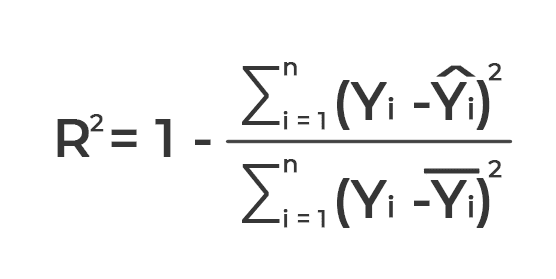

**MSE (Mean Squared Error)**

Measures the average of squared prediction errors.

Lower is better (closer to 0).

Sensitive to large errors (since errors are squared).

"How far off are my predictions on average?"

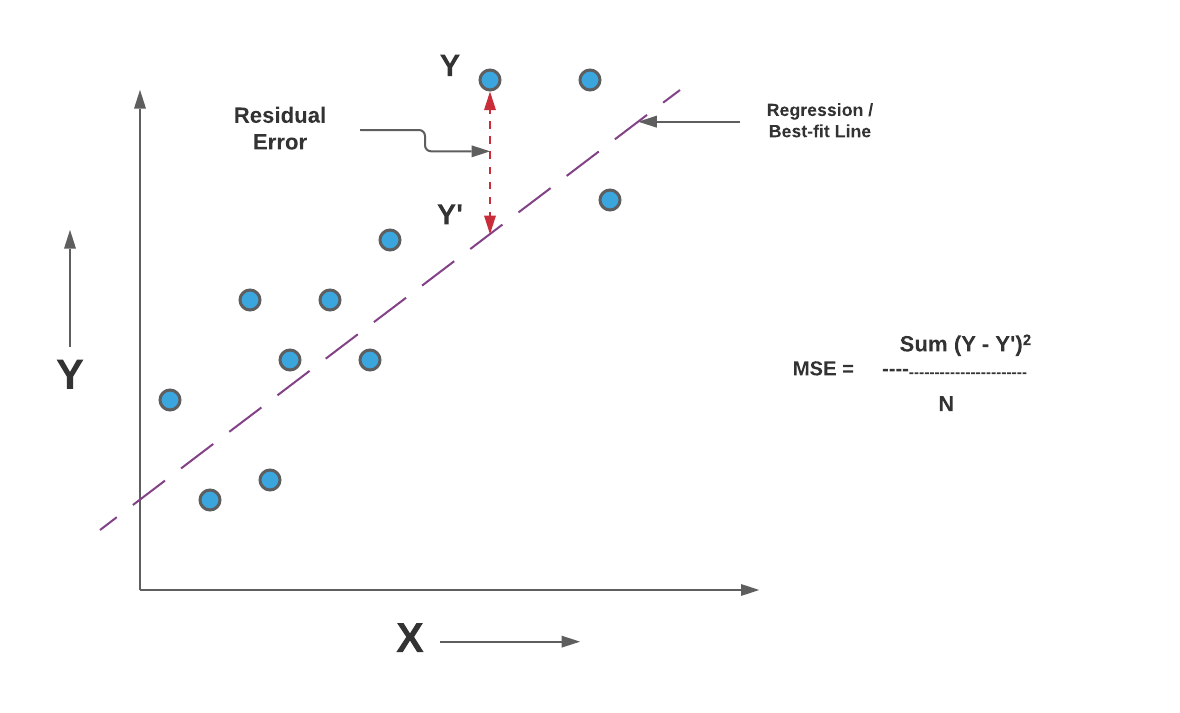

In [27]:
from sklearn.metrics import r2_score, mean_squared_error

# Assuming you have actual y_test and predicted values in predictions
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


R² Score: 0.5758
Mean Squared Error: 0.5559


# Unsupervised Learning (clustering)

In [28]:
from sklearn.datasets import load_iris

# Load the data
iris_data = load_iris()

In [29]:
iris_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [30]:
iris_data["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [31]:
print(iris_data["feature_names"])
iris_data["data"][:10]

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

### KMeans Clustering
<p align="center">
<img src="https://storage.googleapis.com/aihub-c2t-containers-public/release-0.2.0/kfp-components/oob_algorithm/kmeans/assets/kmeans.png" width="800"
</p>

In [32]:
iris_data.data.shape

(150, 4)

In [33]:
from sklearn.cluster import KMeans
kms = KMeans(n_clusters=3, random_state=10)
kms.fit(iris_data.data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",10
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


#### Evaluating the model

In [34]:
kms.cluster_centers_

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

In [35]:
predictions=kms.labels_
print("Prediction for the KMeans Cluster")
print(predictions)

Prediction for the KMeans Cluster
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]
